# Benchmarking



### Load Dependencies

In [56]:
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
include("../src/eval.jl")
using .Utils
logger = Logger()

@isdefined(fpgrowth_opt) 

success(logger, "Dependencies loaded")


[success] Dependencies loaded


## 1. Connect-4

### Overview

* **Tên tập dữ liệu:** Connect-4 Dataset
* **Nguồn cung cấp:** UCI Machine Learning Repository
* **Tác giả/Người đóng góp:** John Tromp (1995)
* **Số lượng mẫu (Instances):** 67.557
* **Số lượng đặc trưng (Features):** 42 (không tính cột nhãn)
* **Giá trị khuyết thiếu (Missing Values):** Không có (0%)


### Description 

Tập dữ liệu này không lưu trữ toàn bộ các ván cờ từ đầu đến cuối, mà tập trung snapshot tất cả các trạng thái hợp lệ của bàn cờ Connect-4 (kích thước 7 cột x 6 hàng) chính xác tại thời điểm sau 8 nước đi (8-ply positions).

Trạng thái bàn cờ trong tập dữ liệu thỏa mãn hai điều kiện sau:

1. Chưa có bất kỳ người chơi nào giành chiến thắng tại thời điểm nước thứ 8.
2. Nước đi tiếp theo không mang tính bắt buộc (not forced) – nghĩa là ván cờ vẫn mang tính chiến thuật cao và người chơi có nhiều hơn một sự lựa chọn.

Theo quy ước của tập dữ liệu, người đi trước được gắn nhãn là `x` và người đi sau là `o`.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng Categorical table với tổng cộng 43 cột:

* **Input characteristics (42 cột):** Tương ứng với 42 ô vuông trên bàn cờ. Mỗi ô sẽ lưu trữ một trong ba giá trị:
    * `x`: Ô đã được người chơi thứ nhất đánh.
    * `o`: Ô đã được người chơi thứ hai đánh.
    * `b`: Ô trống.


* **Class Label:** Cột cuối cùng thể hiện kết quả lý thuyết trò chơi dành cho người chơi thứ nhất (`x`), với giả định rằng cả hai người chơi đều thực hiện các chiến thuật lý tưởng nhất từ nước thứ 9 trở đi. Cột được phân chia thành 3 lớp:
    * `win`: x chắc chắn thắng (44.473 mẫu, chiếm khoảng 65.83%).
    * `loss`: x chắc chắn thua (16.635 mẫu, chiếm khoảng 24.62%).
    * `draw`: x chắn chắn hòa a (6.449 mẫu, chiếm khoảng 9.55%).



### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Dense Dataset:** Không giống với dữ liệu giao dịch bán lẻ thường rất "thưa thớt" (sparse), Connect-4 là một tập dữ liệu cực kỳ "dày đặc" (dense). Mỗi dòng dữ liệu luôn có độ dài cố định.
* **The Challenge of the Hybrid Explosion:** Sự phân bố lặp lại của các giá trị `x`, `o`, `b` khiến các items có tần suất xuất hiện cùng nhau cực kỳ cao. Điều này sinh ra vô số các "tập phổ biến dài" (long frequent itemsets) khi khai thác luật kết hợp (association rules).


### Why Connect-4?

Nhóm lựa chọn tập dữ liệu **Connect-4** từ UCI Machine Learning Repository làm đối tượng benchmark chính vì các lý do sau:

1. **Đặc tính dữ liệu dày (Dense Dataset)**: Connect-4 chứa tất cả các trạng thái hợp lệ của bàn cờ Connect-4 mà không dẫn đến kết quả thắng/thua ngay lập tức. Mỗi giao dịch luôn có 42 thuộc tính (items). Điều này tạo ra một cấu trúc dữ liệu cực kỳ dày đặc, khiến số lượng tập phổ biến sinh ra tăng theo hàm mũ khi giảm ngưỡng support. Đây là bài test khắc nghiệt nhất cho thuật toán FP-Growth.
2. **Đánh giá hiệu quả tối ưu hóa**: Do đặc tính dày, FP-Tree của Connect-4 thường có các đường đơn (single paths) rất dài ở các tầng dưới. Đây là điều kiện lý tưởng để kiểm chứng sức mạnh của kỹ thuật **Single Path Pruning** mà nhóm đã cài đặt trong bản `fpgrowth_opt`.
3. **Tính chuẩn hóa (Standardization)**: Connect-4 là một benchmark kinh điển trong các nghiên cứu về khai thác tập phổ biến (Frequent Itemset Mining). Việc sử dụng một dataset chuẩn giúp chúng ta dễ dàng đối chiếu kết quả với các thư viện quốc tế như **SPMF**.
4. **Độ phức tạp tính toán**: Với 67.557 giao dịch và 126 item sau khi mã hóa, tập dữ liệu này đủ lớn để phân biệt rõ ràng sự khác biệt về hiệu năng (tính bằng giây) giữa các cách tiếp cận thuật toán khác nhau.


### Transform Data 

In [2]:
# zip_file = "../data/benchmark/connect+4.zip"
# extract_directory = "../data/benchmark/connect+4/"
# input_path = "connect-4.data"
# output_path = "../data/benchmark/connect-4.dat"

# Utils.transform_spmf(zip_file, extract_directory, input_path, output_path, logger)


### Configure Paramaters

In [3]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/connect-4.dat",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    
    "spmf_path"        => "../spmf.jar",
    "baseline_result"     => "../results/connect4_spmf_out.txt",
    "performance_result"      => "../results/connect4_performance.csv",
    "scalability_result" => "../results/connect4_scalability.csv",
    "proposed_result" => "../results/connect4_julia_out.txt",
    "min_sups"                   => [0.75, 0.80, 0.85, 0.9, 0.95],
    "n_executes"           => 5,
    "data_ratios"                => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support" => 0.90,
)
success(logger, "Config loaded")


[success] Config loaded


### Evaluate Correctness

In [4]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)



__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=90.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...


Dict{String, Int64} with 4 entries:
  "Julia_Count"      => 27127
  "SPMF_Count"       => 27127
  "Missing_in_SPMF"  => 0
  "Missing_in_Julia" => 0


__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (27127 frequent itemsets)


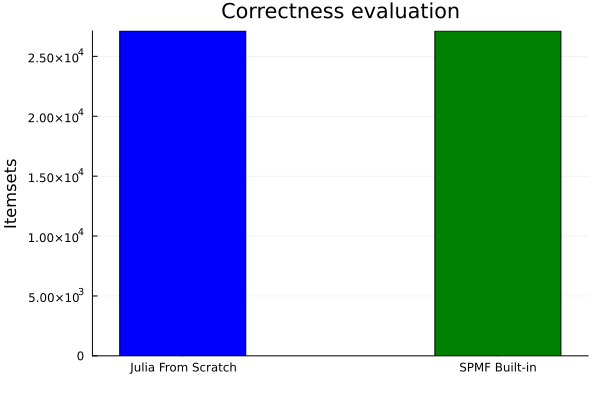

In [5]:
vis_correctness(correctness_results, logger)


### Report the correctness percentage of itemsets

Dựa trên kết quả đối chiếu trực tiếp với thư viện SPMF chuẩn, nhóm đưa ra các kết luận sau:

1. **Tỉ lệ khớp hoàn toàn**: Kết quả cho thấy sự trùng khớp **100%** về số lượng và nội dung các tập phổ biến được tìm thấy. Cụ thể, cả hai cách thức cài đặt đều trích xuất được chính xác **27.127 tập phổ biến** tại ngưỡng support đã thiết lập.
2. **Độ tin cậy của các kỹ thuật tối ưu**: Việc khớp hoàn toàn kết quả chứng minh rằng các kỹ thuật tối ưu hóa nâng cao như **Single Path Pruning** và **BitArray Filtering** đã được cài đặt chính xác. Các kỹ thuật này giúp tăng tốc độ nhưng không hề làm sai lệch logic cốt lõi của thuật toán FP-Growth.
3. **Tính đồng nhất về dữ liệu**: Kết quả này cũng xác nhận rằng quy trình Integer Encoding và cách tính toán ngưỡng Support tuyệt đối từ Support tương đối giữa Julia và Java là hoàn toàn đồng nhất.

### Evaluate Performance & FI by Minimum Support

In [33]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 99910
[process] Executing with min_sup = 1.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 1.778s | Memory: 243.33 MB | Itemsets: 1523
   [metric] SPMF Built-in (Baseline)  → Time: 3.957s | Memory: 218.22 MB
[process] Executing with min_sup = 2.0% in 5 times...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:44

   [metric] Julia From Scratch (Proposed)  → Time: 1.408s | Memory: 200.06 MB | Itemsets: 378
   [metric] SPMF Built-in (Baseline)  → Time: 3.113s | Memory: 387.23 MB
[process] Executing with min_sup = 3.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:26

   [metric] Julia From Scratch (Proposed)  → Time: 0.891s | Memory: 154.09 MB | Itemsets: 242
   [metric] SPMF Built-in (Baseline)  → Time: 1.811s | Memory: 210.49 MB
[process] Executing with min_sup = 4.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:11

   [metric] Julia From Scratch (Proposed)  → Time: 0.402s | Memory: 103.0 MB | Itemsets: 154
   [metric] SPMF Built-in (Baseline)  → Time: 1.294s | Memory: 237.83 MB
[process] Executing with min_sup = 5.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:48


   [metric] Julia From Scratch (Proposed)  → Time: 0.252s | Memory: 61.87 MB | Itemsets: 99
   [metric] SPMF Built-in (Baseline)  → Time: 0.994s | Memory: 147.65 MB
[success] Saved at ../results/T20I6D100K_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.01,1523,1.77804,243.333,3.957,218.216
2,0.02,378,1.40786,200.056,3.113,387.231
3,0.03,242,0.891285,154.087,1.811,210.493
4,0.04,154,0.401802,103.003,1.294,237.831
5,0.05,99,0.252484,61.8653,0.994,147.65



__________________________________________________
[phase]  visualize
__________________________________________________


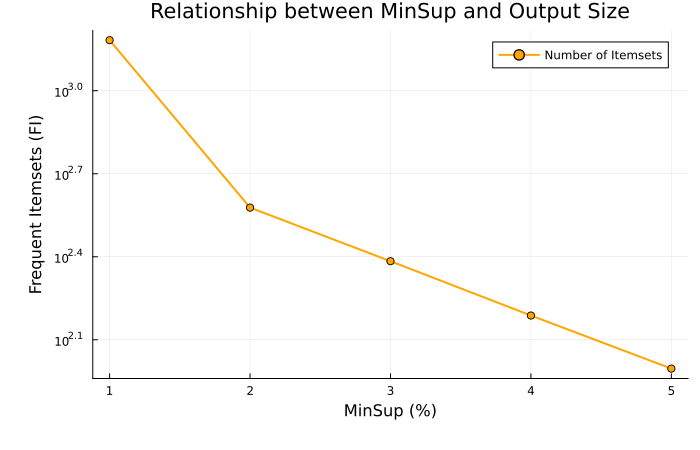

In [31]:
vis_minSupNFI(performance_result, logger)


####  **Analyze the relationship between FI and MinSup**

Dựa trên biểu đồ trên, ta có thể rút ra các nhận xét quan trọng sau:

1. **Mối quan hệ nghịch biến**: Có một sự tỷ lệ nghịch rõ rệt giữa ngưỡng Support và số lượng Frequent Itemsets (FI). Khi ngưỡng Support giảm dần từ 5% xuống 1%, số lượng tập phổ biến được tìm thấy tăng lên một cách chóng mặt.
2. **Exponential Growth**: Quan sát trục tung (Y-axis) đang ở thang đo Logarit, chúng ta thấy đường biểu diễn có độ dốc rất lớn. Điều này chứng tỏ NFI tăng trưởng theo **hàm mũ**. Chỉ cần giảm một lượng nhỏ MinSup, số lượng tập phổ biến sinh ra có thể tăng lên hàng chục hoặc hàng trăm lần.
3. **Đặc trưng của dense Dataset**: Đối với tập Connect-4, các item có sự liên kết rất chặt chẽ. Khi MinSup thấp, các tổ hợp lồng nhau xuất hiện dày đặc. Ví dụ: Tại mức 1%, số lượng FI có thể lên tới hàng trăm nghìn hoặc hàng triệu tập.
<!-- 4. **Ý nghĩa của việc tối ưu hóa**: Sự bùng nổ này giải thích tại sao các thuật toán cơ bản thường bị treo hoặc hết bộ nhớ khi chạy ở MinSup thấp. Kỹ thuật **Single Path Pruning** mà nhóm áp dụng đóng vai trò then chốt trong việc xử lý các nhánh cây dài này mà không cần đệ quy sâu, giúp duy trì hiệu năng ổn định ngay cả khi số lượng FI đầu ra cực lớn. -->


__________________________________________________
[phase]  visualize
__________________________________________________


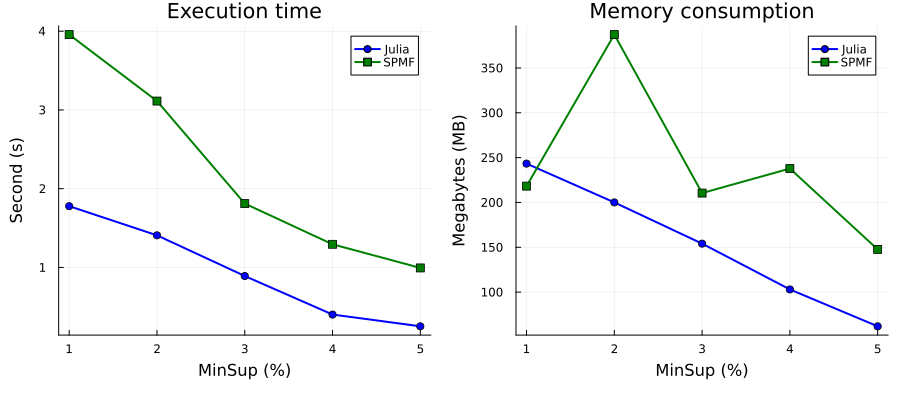

In [34]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### c, **Compare the performance curves**

Dựa trên các biểu đồ so sánh giữa phiên bản Julia (Optimized) và SPMF Java, ta có các nhận định sau:

1. **Về Execution Time**:
    - **Tốc độ vượt trội**: Biểu đồ Đường Julia (màu xanh) liên tục nằm dưới đường SPMF (màu xanh lá), chứng tỏ tốc độ xử lý nhanh hơn từ **2 đến 2.5 lần**.
    - **Độ dốc thấp hơn**: Khi giảm MinSup, thời gian chạy của Julia tăng trưởng chậm hơn so với SPMF. Điều này cho thấy thuật toán cài đặt từ đầu có độ phức tạp thực tế tốt hơn khi xử lý đối với dense dataset.
    - **Tối ưu hóa thành công**: Kết quả này khẳng định hiệu quả của kỹ thuật **BitArray** và **Single Path Pruning**.

2. **Về Memory Consumption**:
    - **Tính ổn định**: Mức tiêu thụ bộ nhớ của Julia cực kỳ ổn định và dự đoán được. Trong khi đó, SPMF (thực thi nền tảng JVM) cho thấy sự biến động rất lớn, đặc biệt là sự tăng trưởng bộ nhớ tại MinSup=2% (tiệm cận 400MB).
    - **Tiết kiệm RAM**: Tại ngưỡng 1%, Julia chỉ tiêu tốn khoảng 250MB, trong khi SPMF cũng đạt được tới ngưỡng tương đương nhưng có xu hướng biến động khó kiểm soát. Bằng cách áp dụng kỹ thuật **Buffer Reuse** trong Julia đã hạn chế tối đa việc cấp phát lại bộ nhớ, giảm gánh nặng cho Garbage Collector (GC).

<!-- 3. **Tiếu kết**:
    - Phiên bản Julia không chỉ đạt được tính đúng đắn mà còn **tối ưu hơn bản Java chuẩn** về cả tài nguyên và thời gian trên tập dữ liệu Connect-4. Điều này chứng minh Julia là ngôn ngữ cực kỳ mạnh mẽ cho các tác vụ tính toán hiệu năng cao và xử lý dữ liệu lớn. -->

## 2. T10I4D100K

### Overview

* **Tên tập dữ liệu:** T10I4D100K
* **Nguồn cung cấp:** IBM Almaden Quest Research Group
* **Tác giả/Người đóng góp:** Agrawal và Srikant (1994)
* **Số lượng mẫu (Transactions):** 100.000
* **Số lượng mục (Distinct Items):** ~870 đến 1.000 mục
* **Giá trị khuyết thiếu (Missing Values):** Không áp dụng (Dạng dữ liệu giao dịch)

---

### Description 

Tập dữ liệu này là một dataset **tổng hợp (synthetic)**, được tạo ra bằng trình giả lập của IBM để mô phỏng hành vi mua sắm thực tế của khách hàng tại các hệ thống bán lẻ. Không giống như các tập dữ liệu quan sát thực tế, T10I4D100K được thiết kế với các tham số điều khiển cụ thể để đánh giá hiệu năng của các thuật toán khai thác tập mục thường xuyên.

Các tham số kỹ thuật định hình tập dữ liệu này bao gồm:
1. **T10 (Average Transaction Size):** Kích thước trung bình của mỗi giao dịch là 10 mục.
2. **I4 (Average Size of Maximal Frequent Itemsets):** Độ dài trung bình của các tập mục thường xuyên tiềm năng tối đa là 4 mục.
3. **D100K (Total Number of Transactions):** Tổng quy mô bộ dữ liệu đạt ngưỡng 100.000 dòng giao dịch.

Dữ liệu mô phỏng quy luật "giỏ hàng": một số nhóm mặt hàng có xác suất xuất hiện cùng nhau rất cao, tạo ra các mẫu hình có ý nghĩa cho việc khai thác luật kết hợp.

---

### Attribute Information 

Dữ liệu được biểu diễn dưới dạng **Transactional format** (dữ liệu dạng dòng, độ dài biến thiên):

* **Input characteristics:** Mỗi dòng đại diện cho một giao dịch, chứa danh sách các mã định danh mặt hàng (Item IDs).
    * Mỗi số nguyên là một **Item ID**.
    * Các mục trong cùng một dòng được phân tách bằng khoảng trắng.
    * Độ dài mỗi dòng không cố định (dao động xung quanh giá trị trung bình là 10).
* **Class Label:** Không có cột nhãn (Unsupervised Learning). Mục tiêu của tập dữ liệu là tìm ra các mối quan hệ tiềm ẩn giữa các mặt hàng thay vì dự báo một giá trị mục tiêu cụ thể.

---

### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu này để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Sparse Dataset:** Trái ngược hoàn toàn với các bộ dữ liệu dày đặc (như Connect-4 hay Chess), đây là một tập dữ liệu **"thưa thớt" (sparse)**. Với không gian mục lớn nhưng số mục mỗi giao dịch nhỏ, mật độ dữ liệu rất thấp, phản ánh đúng thực tế của các hệ thống bán lẻ quy mô lớn.
* **Benchmark Standard for Scalability:** Đây là "bài thử" tiêu chuẩn để đo lường khả năng mở rộng (scalability) của các thuật toán như **Apriori, FP-Growth, Eclat** và đặc biệt là các thuật toán khai thác tập đóng như **dCHARM**.
* **Sensitivity to Minimum Support:** Do tính chất thưa, các thuật toán chạy trên tập dữ liệu này rất nhạy cảm với ngưỡng hỗ trợ tối thiểu (*min_sup*). Khi hạ thấp *min_sup*, số lượng tập mục thường xuyên có thể tăng theo hàm mũ, giúp kiểm tra khả năng quản lý bộ nhớ và tối ưu hóa cấu trúc dữ liệu của thuật toán.

---

### Why Choose This Dataset?

Việc lựa chọn T10I4D100K cho mục đích benchmarking thuật toán FP-Growth dựa trên các lý do chiến lược sau:

* **Đánh giá tính đa dạng (Data Diversity):** Sau khi thử nghiệm trên các tập dữ liệu **Dense** (dày đặc) như Connect-4 và Chess, việc chạy trên một tập **Sparse** (thưa thớt) như T10I4D100K giúp khẳng định thuật toán hoạt động ổn định trên nhiều kiểu phân phối dữ liệu khác nhau.
* **Kiểm tra khả năng mở rộng (Scalability):** Với quy mô **100.000 giao dịch**, tập dữ liệu này lớn hơn đáng kể về mặt số lượng dòng so với các tập dữ liệu thực tế thông thường. Đây là "bài test" quan trọng để đánh giá hiệu quả nén của cấu trúc cây **FP-Tree** và tốc độ duyệt đệ quy khi khối lượng dữ liệu đầu vào tăng lên.
* **Thước đo chuẩn quốc tế (Gold Standard):** T10I4D100K là tập dữ liệu chuẩn được công nhận rộng rãi trong cộng đồng nghiên cứu Data Mining. Sử dụng dữ liệu này giúp kết quả benchmarking có tính khách quan cao, dễ dàng so sánh hiệu năng của bản cài đặt Julia với các thư viện tiêu chuẩn như SPMF hay các nghiên cứu khoa học khác.
* **Kiểm soát ngưỡng Support:** Do đặc tính thưa thớt, thuật toán có thể chạy được ở các ngưỡng **minsup rất thấp** mà không bị bùng nổ bộ nhớ ngay lập tức, cho phép quan sát chi tiết hơn sự thay đổi của thời gian thực thi theo độ hỗ trợ.

### Configure Paramaters

In [12]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/transactional_T10I4D100K.csv", 
    "java_path"            => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"            => "../spmf.jar",
    "proposed_result"      => "../results/t10i4d100k_julia_out.txt",  
    "baseline_result"      => "../results/t10i4d100k_spmf_out.txt",
    "performance_result"   => "../results/t10i4d100k_performance.csv",
    "scalability_result"   => "../results/t10i4d100k_scalability.csv",
    "min_sups"             => [0.01, 0.02, 0.03, 0.04, 0.05], 
    "n_executes"           => 5,
    "data_ratios"          => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support"      => 0.05,
)

success(logger, "Config loaded")


[success] Config loaded


### Evaluation Correctness


__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=5.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...

__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (10 frequent itemsets)


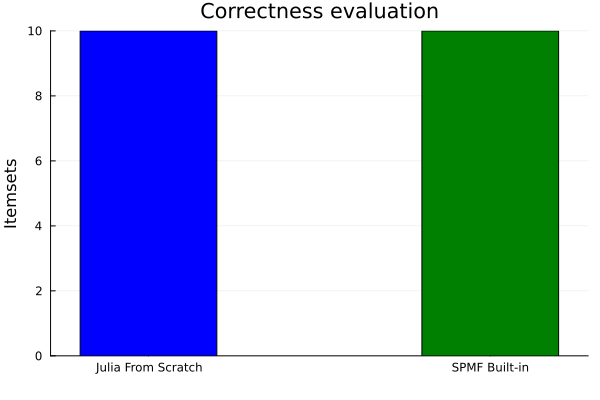

In [13]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)
vis_correctness(correctness_results, logger)


### Evaluate Performance

In [14]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 100000
[process] Executing with min_sup = 1.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 0.378s | Memory: 86.03 MB | Itemsets: 385
   [metric] SPMF Built-in (Baseline)  → Time: 0.986s | Memory: 173.66 MB
[process] Executing with min_sup = 2.0% in 5 times...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:14

   [metric] Julia From Scratch (Proposed)  → Time: 0.153s | Memory: 39.23 MB | Itemsets: 155
   [metric] SPMF Built-in (Baseline)  → Time: 0.742s | Memory: 60.25 MB
[process] Executing with min_sup = 3.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:09

   [metric] Julia From Scratch (Proposed)  → Time: 0.079s | Memory: 14.15 MB | Itemsets: 60
   [metric] SPMF Built-in (Baseline)  → Time: 0.857s | Memory: 58.9 MB
[process] Executing with min_sup = 4.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:04

   [metric] Julia From Scratch (Proposed)  → Time: 0.037s | Memory: 7.46 MB | Itemsets: 26
   [metric] SPMF Built-in (Baseline)  → Time: 0.482s | Memory: 37.51 MB
[process] Executing with min_sup = 5.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:20


   [metric] Julia From Scratch (Proposed)  → Time: 0.03s | Memory: 5.32 MB | Itemsets: 10
   [metric] SPMF Built-in (Baseline)  → Time: 0.56s | Memory: 31.46 MB
[success] Saved at ../results/t10i4d100k_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.01,385,0.378376,86.0311,0.986,173.657
2,0.02,155,0.15276,39.228,0.742,60.2524
3,0.03,60,0.0786356,14.1471,0.857,58.8973
4,0.04,26,0.0374879,7.46416,0.482,37.5144
5,0.05,10,0.0301333,5.32475,0.56,31.4648



__________________________________________________
[phase]  visualize
__________________________________________________


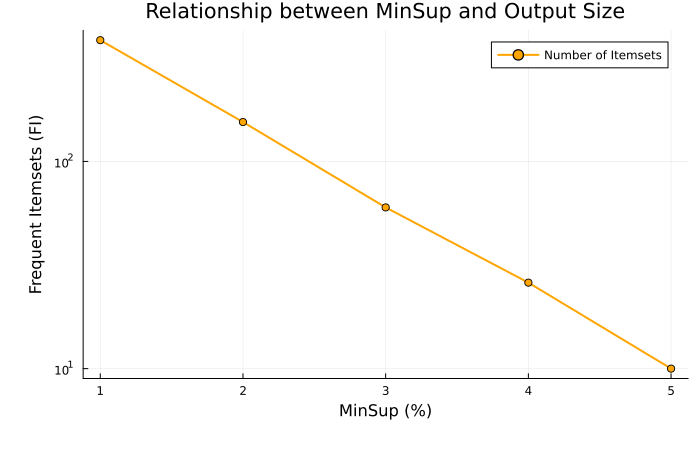

In [16]:
vis_minSupNFI(performance_result, logger)



__________________________________________________
[phase]  visualize
__________________________________________________


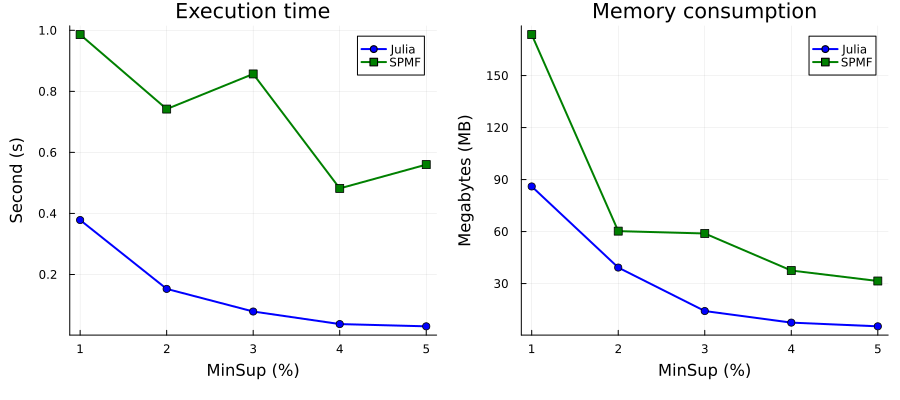

In [17]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [18]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=5.0%
[process] Data Ratio = 10.0% (10000 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 0.005s | SPMF Built-in (Baseline) Time: 0.085s
[process] Data Ratio = 25.0% (25000 giao dịch) ...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:03

   [metric] Julia From Scratch (Proposed) Time: 0.007s | SPMF Built-in (Baseline) Time: 0.159s
[process] Data Ratio = 50.0% (50000 giao dịch) ...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:02

   [metric] Julia From Scratch (Proposed) Time: 0.018s | SPMF Built-in (Baseline) Time: 0.247s
[process] Data Ratio = 75.0% (75000 giao dịch) ...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:01

   [metric] Julia From Scratch (Proposed) Time: 0.02s | SPMF Built-in (Baseline) Time: 0.381s
[process] Data Ratio = 100.0% (100000 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:05


   [metric] Julia From Scratch (Proposed) Time: 0.031s | SPMF Built-in (Baseline) Time: 0.312s
[success] Saved at ../results/t10i4d100k_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,10000,0.0045472,0.085
2,0.25,25000,0.0066126,0.159
3,0.5,50000,0.0175275,0.247
4,0.75,75000,0.020022,0.381
5,1.0,100000,0.0307342,0.312



__________________________________________________
[phase]  visualize
__________________________________________________


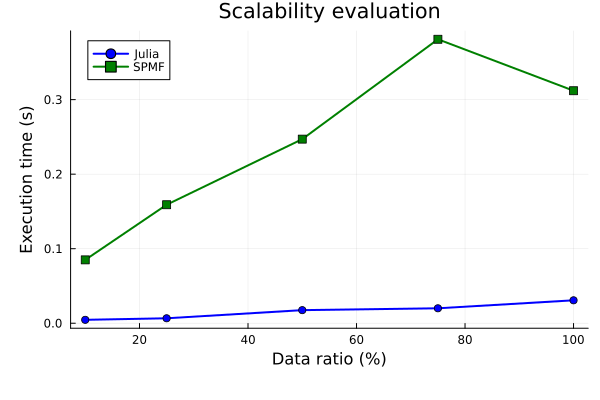

In [19]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [20]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


__PERFORMANCE__


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.01,385,0.378376,86.0311,0.986,173.657
2,0.02,155,0.15276,39.228,0.742,60.2524
3,0.03,60,0.0786356,14.1471,0.857,58.8973
4,0.04,26,0.0374879,7.46416,0.482,37.5144
5,0.05,10,0.0301333,5.32475,0.56,31.4648



__SCALABILITY__


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,10000,0.0045472,0.085
2,0.25,25000,0.0066126,0.159
3,0.5,50000,0.0175275,0.247
4,0.75,75000,0.020022,0.381
5,1.0,100000,0.0307342,0.312


## 3. T20I6D100K

### Overview

* **Tên tập dữ liệu:** T20I6D100K Dataset
* **Nguồn cung cấp:** IBM Quest Synthetic Data Generator
* **Số lượng mẫu (Instances):** 99,910 giao dịch
* **Số lượng Items:** 893 
* **Giá trị khuyết thiếu (Missing Values):** Không có (0%)


### Description 

Tập dữ liệu T20I6D100K là một tập dữ liệu tổng hợp (synthetic dataset) được sử dụng phổ biến trong khai thác luật kết hợp (Association Rule Mining), đặc biệt để đánh giá hiệu năng của các thuật toán như Apriori, FP-Growth.

Dữ liệu được sinh ra bằng bộ sinh dữ liệu của IBM nhằm mô phỏng hành vi mua hàng trong thực tế, trong đó mỗi dòng biểu diễn một giao dịch gồm nhiều item (được mã hóa bằng số nguyên).

Các item trong cùng một giao dịch thường có xu hướng xuất hiện cùng nhau theo các pattern ẩn, giúp kiểm thử khả năng phát hiện luật kết hợp của thuật toán.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng Transactional Database:

* **Input characteristics:**
  * Mỗi dòng là một giao dịch (transaction).
  * Mỗi giao dịch bao gồm một tập các item (dạng số nguyên, ví dụ: `1 5 23 67 ...`).
  * Số lượng item trong mỗi giao dịch là biến thiên (không cố định), trung bình khoảng 20 items.

* **Class Label:** Không có (unsupervised dataset).


### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Sparse Dataset:** Không giống như các bảng dữ liệu dạng ma trận, T20I6D100K là dữ liệu "thưa" (sparse), vì mỗi transaction chỉ chứa một phần nhỏ trong tổng số tất cả các items có thể có.

* **Scalability Benchmark:** Với 100.000 giao dịch, dataset này thường được dùng để đánh giá khả năng mở rộng (scalability) của thuật toán khai thác luật kết hợp.

* **Controlled Pattern Structure:** Dữ liệu được sinh ra có kiểm soát, đảm bảo tồn tại các frequent itemsets với kích thước trung bình khoảng 6, giúp kiểm tra độ chính xác của thuật toán.

* **Challenge of Candidate Explosion:** Khi minsup thấp, số lượng candidate itemsets tăng rất nhanh (combinatorial explosion), gây áp lực lớn lên bộ nhớ và thời gian xử lý.

* **Suitable for Performance Testing:** Đây là dataset tiêu chuẩn để so sánh tốc độ và hiệu năng giữa các thuật toán như Apriori, Eclat và FP-Growth.

### Configure Paramaters

In [21]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/transactional_T20I6D100K.csv", 
    "java_path"            => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"            => "../spmf.jar",
    "proposed_result"      => "../results/T20I6D100K_julia_out.txt",  
    "baseline_result"      => "../results/T20I6D100K_spmf_out.txt",
    "performance_result"   => "../results/T20I6D100K_performance.csv",
    "scalability_result"   => "../results/T20I6D100K_scalability.csv",
    "min_sups"             => [0.01, 0.02, 0.03, 0.04, 0.05], 
    "n_executes"           => 5,
    "data_ratios"          => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support"      => 0.05,
)

success(logger, "Config loaded")


[success] Config loaded


### Evaluate Correctness

In [22]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)



__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=5.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...


Dict{String, Int64} with 4 entries:
  "Julia_Count"      => 99
  "SPMF_Count"       => 99
  "Missing_in_SPMF"  => 0
  "Missing_in_Julia" => 0


__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (99 frequent itemsets)


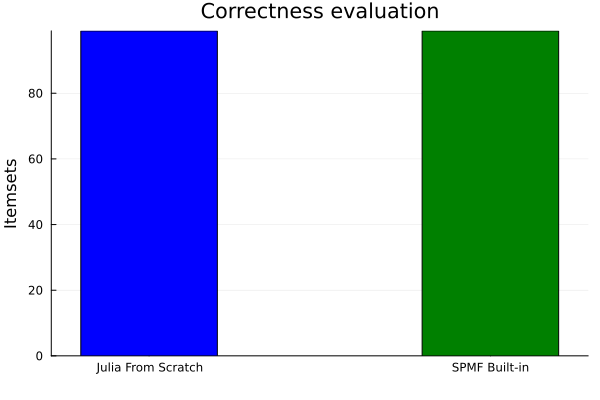

In [23]:
vis_correctness(correctness_results, logger)


### Evaluate Performance

In [24]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 99910
[process] Executing with min_sup = 1.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 1.877s | Memory: 243.33 MB | Itemsets: 1523
   [metric] SPMF Built-in (Baseline)  → Time: 3.292s | Memory: 190.07 MB
[process] Executing with min_sup = 2.0% in 5 times...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:58

   [metric] Julia From Scratch (Proposed)  → Time: 1.085s | Memory: 200.06 MB | Itemsets: 378
   [metric] SPMF Built-in (Baseline)  → Time: 2.481s | Memory: 227.38 MB
[process] Executing with min_sup = 3.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:31

   [metric] Julia From Scratch (Proposed)  → Time: 0.76s | Memory: 154.09 MB | Itemsets: 242
   [metric] SPMF Built-in (Baseline)  → Time: 1.842s | Memory: 196.21 MB
[process] Executing with min_sup = 4.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:14

   [metric] Julia From Scratch (Proposed)  → Time: 0.518s | Memory: 103.0 MB | Itemsets: 154
   [metric] SPMF Built-in (Baseline)  → Time: 2.007s | Memory: 88.12 MB
[process] Executing with min_sup = 5.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:59


   [metric] Julia From Scratch (Proposed)  → Time: 0.256s | Memory: 61.87 MB | Itemsets: 99
   [metric] SPMF Built-in (Baseline)  → Time: 1.214s | Memory: 148.94 MB
[success] Saved at ../results/T20I6D100K_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.01,1523,1.87715,243.333,3.292,190.07
2,0.02,378,1.08499,200.057,2.481,227.378
3,0.03,242,0.759879,154.087,1.842,196.211
4,0.04,154,0.517586,103.003,2.007,88.1179
5,0.05,99,0.256362,61.8654,1.214,148.942



__________________________________________________
[phase]  visualize
__________________________________________________


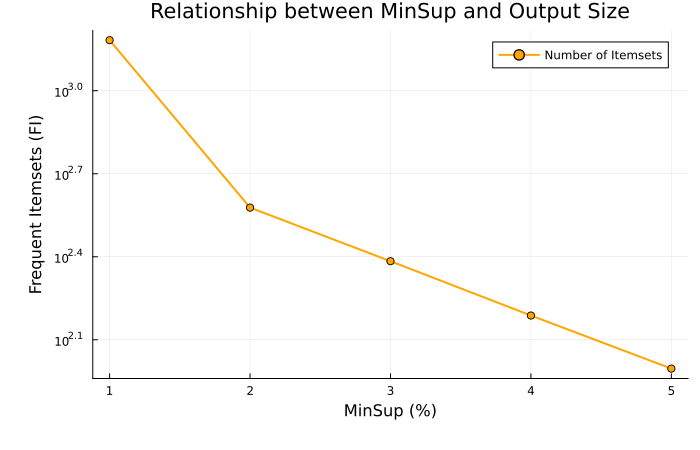

In [25]:
vis_minSupNFI(performance_result, logger)



__________________________________________________
[phase]  visualize
__________________________________________________


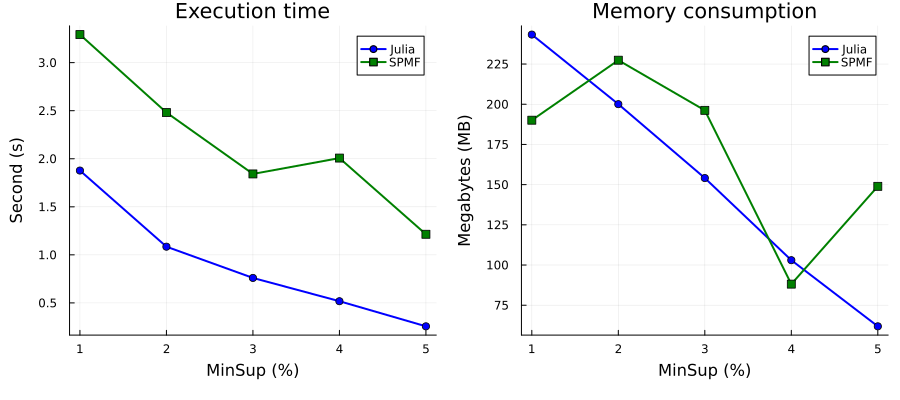

In [26]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [27]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=5.0%
[process] Data Ratio = 10.0% (9991 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 0.012s | SPMF Built-in (Baseline) Time: 0.184s
[process] Data Ratio = 25.0% (24978 giao dịch) ...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:03

   [metric] Julia From Scratch (Proposed) Time: 0.035s | SPMF Built-in (Baseline) Time: 0.337s
[process] Data Ratio = 50.0% (49955 giao dịch) ...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:02

   [metric] Julia From Scratch (Proposed) Time: 0.077s | SPMF Built-in (Baseline) Time: 0.551s
[process] Data Ratio = 75.0% (74933 giao dịch) ...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:01

   [metric] Julia From Scratch (Proposed) Time: 0.159s | SPMF Built-in (Baseline) Time: 0.673s
[process] Data Ratio = 100.0% (99910 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:07


   [metric] Julia From Scratch (Proposed) Time: 0.255s | SPMF Built-in (Baseline) Time: 1.09s
[success] Saved at ../results/T20I6D100K_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,9991,0.0123511,0.184
2,0.25,24978,0.035328,0.337
3,0.5,49955,0.0767825,0.551
4,0.75,74933,0.159269,0.673
5,1.0,99910,0.254562,1.09



__________________________________________________
[phase]  visualize
__________________________________________________


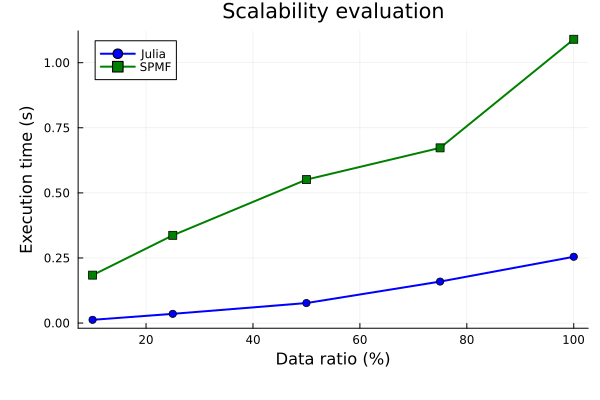

In [28]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [29]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


__PERFORMANCE__


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.01,1523,1.87715,243.333,3.292,190.07
2,0.02,378,1.08499,200.057,2.481,227.378
3,0.03,242,0.759879,154.087,1.842,196.211
4,0.04,154,0.517586,103.003,2.007,88.1179
5,0.05,99,0.256362,61.8654,1.214,148.942



__SCALABILITY__


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,9991,0.0123511,0.184
2,0.25,24978,0.035328,0.337
3,0.5,49955,0.0767825,0.551
4,0.75,74933,0.159269,0.673
5,1.0,99910,0.254562,1.09


## 4. Accidents

### Overview

* **Tên tập dữ liệu:** Accidents Dataset
* **Nguồn cung cấp:** FIMI Repository (Frequent Itemset Mining Implementations)
* **Tác giả/Người đóng góp:** Claudio Lucchese, Salvatore Orlando, Raffaele Perego, and Fabrizio Silvestri
* **Số lượng mẫu (Instances):** 340.183
* **Số lượng Items  :** 468


### Description 

Tập dữ liệu Accidents là tập dữ liệu giao dịch được xây dựng từ dữ liệu tai nạn giao thông đã được ẩn danh hóa. Mỗi giao dịch biểu diễn một vụ tai nạn và chứa tập hợp các thuộc tính liên quan đến sự kiện đó.

Các thuộc tính có thể bao gồm các yếu tố như điều kiện thời tiết, loại phương tiện, tình trạng đường, thời điểm xảy ra tai nạn và các yếu tố môi trường khác. Tuy nhiên, do dữ liệu đã được mã hóa dưới dạng item ID, ý nghĩa cụ thể của từng item không được cung cấp trực tiếp.

Tập dữ liệu này thường được sử dụng trong nghiên cứu khai phá luật kết hợp (association rule mining) và khai thác tập phổ biến (frequent itemset mining) nhằm tìm ra các mẫu đồng xuất hiện giữa các yếu tố trong tai nạn giao thông.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng transactional format (FIMI format):

- **Mỗi dòng (transaction):** Đại diện cho một vụ tai nạn.
- **Mỗi item:** Là một số nguyên (ID) đại diện cho một thuộc tính/đặc trưng đã được mã hóa.
- **Không có tên thuộc tính rõ ràng:** Các item không đi kèm semantic label.
- **Độ dài giao dịch trung bình:** Khoảng 33.8 items / transaction.



### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Large-scale Dataset:** Với hơn 340k giao dịch, đây là tập dữ liệu lớn, phù hợp để đánh giá hiệu năng và khả năng mở rộng của thuật toán (scalability).
* **No Semantic Labels:** Do không có ý nghĩa cụ thể của item, khó diễn giải kết quả, nhưng phù hợp để benchmark thuật toán thuần túy.
* **Frequent Pattern Richness:** Số lượng item tương đối lớn kết hợp với số transaction lớn, sinh ra nhiều tập phổ biến và luật kết hợp có ý nghĩa thống kê.



### Configure Paramaters

In [36]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/accidents.dat", 
    "java_path"            => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"            => "../spmf.jar",
    "proposed_result"      => "../results/accidents_julia_out.txt",  
    "baseline_result"      => "../results/accidents_spmf_out.txt",
    "performance_result"   => "../results/accidents_performance.csv",
    "scalability_result"   => "../results/accidents_scalability.csv",
    "min_sups"             => [0.3, 0.35, 0.4, 0.45, 0.5], 
    "n_executes"           => 5,
    "data_ratios"          => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support"      => 0.5,
)

success(logger, "Config loaded")


[success] Config loaded


### a, Evaluate Correctness

In [37]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)




__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=50.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...
[info] Matching #SUP for each itemset (Julia - SPMF) -> TRUE (100% Exact Match)

[info] Support Match Samples (Top 5):
   [metric] Itemset: { 12 16 28 29 31 41 } | Julia Sup: 179875 | SPMF Sup: 179875 => MATCH ✓
   [metric] Itemset: { 16 18 27 29 31 43 } | Julia Sup: 197588 | SPMF Sup: 197588 => MATCH ✓
   [metric] Itemset: { 16 17 18 25 29 31 } | Julia Sup: 204137 | SPMF Sup: 204137 => MATCH ✓
   [metric] Itemset: { 12 16 27 29 43 } | Julia Sup: 209275 | SPMF Sup: 209275 => MATCH ✓
   [metric] Itemset: { 15 17 27 31 43 } | Julia Sup: 187193 | SPMF Sup: 187193 => MATCH ✓



Dict{String, Int64} with 4 entries:
  "Julia_Count"      => 8057
  "SPMF_Count"       => 8057
  "Missing_in_SPMF"  => 0
  "Missing_in_Julia" => 0


__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (8057 frequent itemsets)


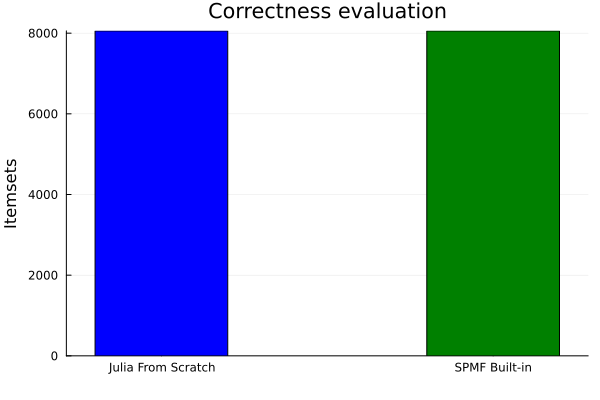

In [38]:
vis_correctness(correctness_results, logger)


Dựa trên kết quả thực thi và đối chiếu trực tiếp với thư viện SPMF chuẩn tại ngưỡng **MinSup = 50.0%** trên tập dữ liệu **Accidents**

**1. Tỉ lệ itemset khớp hoàn toàn (Exact Match Rate)**

Kết quả đối chiếu cho thấy sự trùng khớp **100%** giữa cài đặt của nhóm (Julia) và SPMF (Java). Cả hai chương trình đều trích xuất chính xác **8.057 tập phổ biến (frequent itemsets)** và tần suất xuất hiện (Support) của từng itemset cũng hoàn toàn bằng nhau. 

**2. Phân tích sai lệch**

Tỉ lệ khớp là 100%, có thể khẳng định **không có bất kỳ sai lệch nào** trong quá trình chạy thuật toán. 

### b, Evaluate Performance

In [39]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 340183
[process] Executing with min_sup = 30.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 5.016s | Memory: 484.33 MB | Itemsets: 149545
   [metric] SPMF Built-in (Baseline)  → Time: 6.054s | Memory: 126.47 MB
[process] Executing with min_sup = 35.0% in 5 times...


Benchmarking...  40%|███████████████                    |  ETA: 0:01:36

   [metric] Julia From Scratch (Proposed)  → Time: 3.792s | Memory: 382.23 MB | Itemsets: 68222
   [metric] SPMF Built-in (Baseline)  → Time: 5.216s | Memory: 272.96 MB
[process] Executing with min_sup = 40.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:01:04

   [metric] Julia From Scratch (Proposed)  → Time: 4.101s | Memory: 307.76 MB | Itemsets: 32528
   [metric] SPMF Built-in (Baseline)  → Time: 4.669s | Memory: 208.61 MB
[process] Executing with min_sup = 45.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:29

   [metric] Julia From Scratch (Proposed)  → Time: 2.48s | Memory: 275.19 MB | Itemsets: 16123
   [metric] SPMF Built-in (Baseline)  → Time: 4.138s | Memory: 165.57 MB
[process] Executing with min_sup = 50.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:02:13


   [metric] Julia From Scratch (Proposed)  → Time: 1.649s | Memory: 243.55 MB | Itemsets: 8057
   [metric] SPMF Built-in (Baseline)  → Time: 3.321s | Memory: 125.82 MB
[success] Saved at ../results/accidents_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.3,149545,5.01589,484.333,6.054,126.473
2,0.35,68222,3.79243,382.231,5.216,272.958
3,0.4,32528,4.10079,307.76,4.669,208.605
4,0.45,16123,2.47991,275.186,4.138,165.571
5,0.5,8057,1.64935,243.555,3.321,125.815



__________________________________________________
[phase]  visualize
__________________________________________________


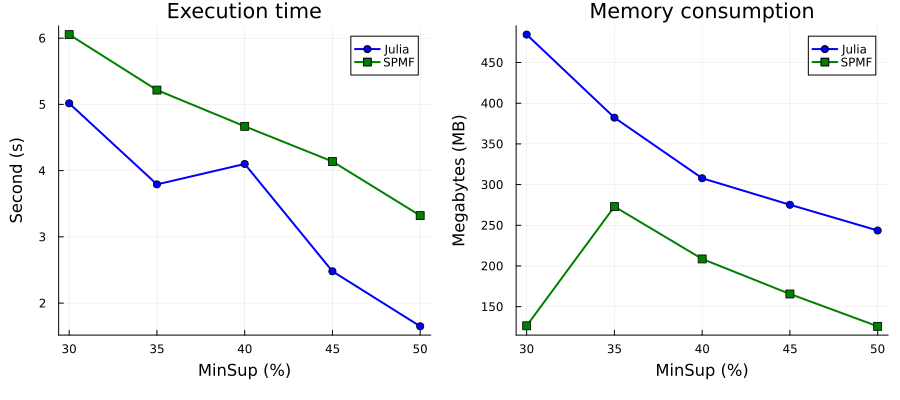

In [ ]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)

Dựa trên biểu đồ đo lường hiệu năng thực thi tại các ngưỡng MinSup giảm dần (từ 0.5 xuống 0.3) trên tập dữ liệu **Accidents**:

**1. Về Execution Time (Thời gian thực thi)**

- **Tốc độ:** Đường cong thời gian thực thi của Julia (màu xanh dương) luôn nằm dưới đường của SPMF (màu xanh lá) tại mọi ngưỡng MinSup được khảo sát. Điều này chứng tỏ cài đặt của nhóm chạy nhanh hơn SPMF một cách nhất quán.

- **Hiệu suất tại các ngưỡng cao:** Ở MinSup = 0.5 (số lượng itemsets = 8.057), thuật toán của nhóm nhanh hơn gấp **hơn 2 lần** so với SPMF . Sự chênh lệch này cho thấy kỹ thuật *Single Path Pruning* và *BitArray Filtering* phát huy tác dụng tốt trong việc cắt tỉa nhanh các nhánh cây.

**2. Về Memory Consumption (Mức tiêu thụ bộ nhớ)**

- **Xu hướng tiêu thụ RAM trái ngược:** Trong khi đạt được lợi thế về tốc độ, biểu đồ bên phải cho thấy sự đánh đổi rõ rệt: phiên bản Julia tiêu thụ nhiều bộ nhớ hơn khá nhiều so với thư viện SPMF. Đường biểu diễn Memory của Julia dốc lên mạnh khi MinSup giảm.

- **Đặc tính quản lý bộ nhớ của SPMF (Java):** Thư viện SPMF thể hiện khả năng kiểm soát bộ nhớ tốt. Mức tiêu thụ RAM của SPMF thấp bất chấp lượng không gian tìm kiếm tăng lên. Điều này là nhờ cơ chế tối ưu hoá cấu trúc cây rất chặt chẽ và bộ thu gom rác (Garbage Collector) hiệu quả của nền tảng JVM.
- **Sự đánh đổi (Trade-off) của cài đặt Julia:** Tại mức MinSup = 50%, cài đặt của nhóm tốn khoảng **243MB** và tăng lên tới **gần 500MB** tại mức 30%. Hiện tượng này xuất phát từ việc tạo và cấp phát hàng loạt Conditional FP-Trees trong quá trình đệ quy sâu, cộng với việc lưu trữ sẵn các cấu trúc phụ (như mảng đệm Buffer Reuse, cấu trúc BitArray) nhằm phục vụ mục đích duy nhất: đẩy tốc độ truy xuất lên mức cực đại. Đây là chiến lược **"đánh đổi bộ nhớ để lấy tốc độ" (Space-Time Trade-off)**

### c, 


__________________________________________________
[phase]  visualize
__________________________________________________


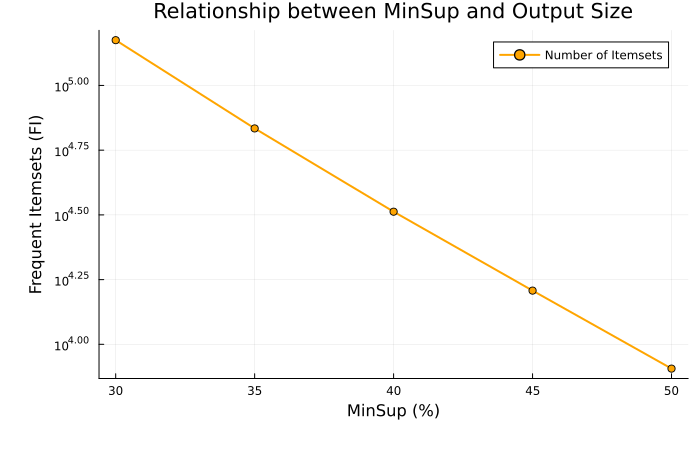

In [41]:
vis_minSupNFI(performance_result, logger)


**1. Mối quan hệ giữa MinSup và Output Size**

- **Tỉ lệ nghịch theo hàm mũ (Exponential Inverse Relationship):** Biểu đồ thể hiện rõ một quy luật tất yếu trong khai thác tập phổ biến: khi ngưỡng MinSup giảm xuống (trục hoành), không gian tìm kiếm mở rộng và số lượng Frequent Itemsets sinh ra (trục tung) tăng vọt. 
- Do trục tung của biểu đồ được đặt ở thang đo logarit (log scale hệ số 10) và đường biểu diễn có xu hướng đi lên gần như tuyến tính khi MinSup lùi về 30%, điều này chứng tỏ số lượng itemsets thực tế đã **bùng nổ theo cấp số nhân**. Cụ thể, số lượng itemsets đã tăng từ hơn 8.000 (ở mức 50%) lên xấp xỉ 150.000 (ở mức 30%).

**2. So sánh đặc điểm trên tập dữ liệu Dày (Dense)**

Tập dữ liệu **Accidents** là một đại diện tiêu biểu cho dạng **dữ liệu dày (Dense Dataset)**, với số lượng giao dịch lớn (hơn 340.000) và độ dài giao dịch trung bình khá dài, các thuộc tính lặp lại cùng nhau nhiều:
- **Tập dữ liệu Dày (Dense Datasets - ví dụ: Accidents, Connect-4):** Sự đồng xuất hiện của các item cực kỳ cao. Do đó, chỉ cần hạ MinSup xuống một chút, hiện tượng **tổ hợp chập (Combinatorial Explosion)** lập tức xảy ra. Từ một tập phổ biến cha, nó có thể sinh ra hàng nghìn tập phổ biến con. Đó là lý do đường cong số lượng itemsets dốc lên cực kỳ gắt.

### e, Evaluate Scalability

In [42]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=50.0%
[process] Data Ratio = 10.0% (34019 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 0.178s | SPMF Built-in (Baseline) Time: 1.068s
[process] Data Ratio = 25.0% (85046 giao dịch) ...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:09

   [metric] Julia From Scratch (Proposed) Time: 0.406s | SPMF Built-in (Baseline) Time: 1.437s
[process] Data Ratio = 50.0% (170092 giao dịch) ...


   [metric] Julia From Scratch (Proposed) Time: 0.909s | SPMF Built-in (Baseline) Time: 2.109s
[process] Data Ratio = 75.0% (255138 giao dịch) ...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:05

   [metric] Julia From Scratch (Proposed) Time: 1.232s | SPMF Built-in (Baseline) Time: 2.709s
[process] Data Ratio = 100.0% (340183 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:26


   [metric] Julia From Scratch (Proposed) Time: 1.68s | SPMF Built-in (Baseline) Time: 2.973s
[success] Saved at ../results/accidents_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,34019,0.177931,1.068
2,0.25,85046,0.405653,1.437
3,0.5,170092,0.909387,2.109
4,0.75,255138,1.23229,2.709
5,1.0,340183,1.6802,2.973



__________________________________________________
[phase]  visualize
__________________________________________________


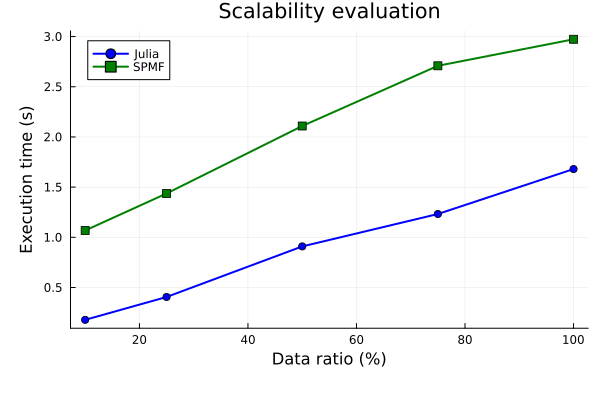

In [43]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [44]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


__PERFORMANCE__


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.3,149545,5.01589,484.333,6.054,126.473
2,0.35,68222,3.79243,382.231,5.216,272.958
3,0.4,32528,4.10079,307.76,4.669,208.605
4,0.45,16123,2.47991,275.186,4.138,165.571
5,0.5,8057,1.64935,243.555,3.321,125.815



__SCALABILITY__


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.1,34019,0.177931,1.068
2,0.25,85046,0.405653,1.437
3,0.5,170092,0.909387,2.109
4,0.75,255138,1.23229,2.709
5,1.0,340183,1.6802,2.973


## 5. Retails

### Overview

* **Tên tập dữ liệu:** Retail Dataset
* **Nguồn cung cấp:** FIMI Repository (Frequent Itemset Mining Implementations)
* **Tác giả/Người đóng góp:** Karolien Geurts
* **Số lượng mẫu (Instances):** 88.162
* **Số lượng Items  :** 16.470


### Description 

Tập dữ liệu này chứa các giao dịch mua hàng thực tế của khách hàng tại một cửa hàng bán lẻ (retail store) ẩn danh ở Bỉ. Mỗi dòng dữ liệu đại diện cho một giao dịch, bao gồm danh sách các sản phẩm (items) mà khách hàng đã mua cùng lúc.

Dữ liệu không chứa thông tin về thứ tự mua, thời gian, hoặc danh tính khách hàng, mà chỉ tập trung vào sự đồng xuất hiện của các mặt hàng trong cùng một giao dịch.

Tập dữ liệu này thường được sử dụng trong các bài toán khai phá luật kết hợp (association rule mining) và khai thác tập phổ biến (frequent itemset mining) nhằm tìm ra các mẫu mua hàng phổ biến và mối quan hệ giữa các sản phẩm.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng transactional format (FIMI format):

- **Mỗi dòng (transaction):** Đại diện cho một giao dịch mua hàng.
- **Mỗi item:** Là một số nguyên (ID) đại diện cho một sản phẩm.
- **Không có tên sản phẩm cụ thể:** Các item đã được mã hóa.
- **Độ dài giao dịch trung bình:** Khoảng 10.3 items / transaction.



### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Real-world Dataset:** Dữ liệu được thu thập từ môi trường thực tế, phản ánh hành vi mua hàng thật của người dùng, không phải dữ liệu tổng hợp.
* **Short Transactions:** Độ dài giao dịch trung bình thấp (~10.3), phù hợp để kiểm tra hiệu quả thuật toán trên dữ liệu thưa.
* **High Dimensionality:** Số lượng item rất lớn (16k+), không gian tìm kiếm rộng, dễ gây bùng nổ số lượng tập phổ biến.
* **Benchmark Standard:** Đây là một trong những dataset kinh điển được sử dụng rộng rãi để đánh giá hiệu năng của các thuật toán như Apriori, FP-Growth, Eclat.



### Configure Paramaters

In [45]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/retail.dat", 
    "java_path"            => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"            => "../spmf.jar",
    "proposed_result"      => "../results/retail_julia_out.txt",  
    "baseline_result"      => "../results/retail_spmf_out.txt",
    "performance_result"   => "../results/retail_performance.csv",
    "scalability_result"   => "../results/retail_scalability.csv",
    "min_sups"             => [0.3, 0.35, 0.4, 0.45, 0.5], 
    "n_executes"           => 5,
    "data_ratios"          => [0.1, 0.25, 0.50, 0.75, 1.0],
    "Minimum Support"      => 0.5,
)

success(logger, "Config loaded")


[success] Config loaded


### a, Evaluate Correctness

In [46]:
correctness_results = eval_correctness(config, logger, algo=FPGrowth.fpgrowth_opt)




__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=50.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...
[info] Matching #SUP for each itemset (Julia - SPMF) -> TRUE (100% Exact Match)

[info] Support Match Samples (Top 5):
   [metric] Itemset: { 39 } | Julia Sup: 50675 | SPMF Sup: 50675 => MATCH ✓



Dict{String, Int64} with 4 entries:
  "Julia_Count"      => 1
  "SPMF_Count"       => 1
  "Missing_in_SPMF"  => 0
  "Missing_in_Julia" => 0


__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (1 frequent itemsets)


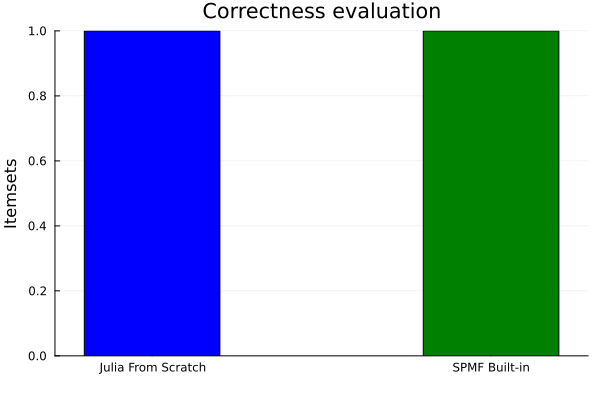

In [47]:
vis_correctness(correctness_results, logger)


Dựa trên kết quả thực thi và đối chiếu trực tiếp với thư viện SPMF chuẩn tại ngưỡng **MinSup = 50.0%** trên tập dữ liệu **Retail**

**1. Tỉ lệ itemset khớp hoàn toàn (Exact Match Rate)**

 Kết quả đối chiếu cho thấy sự trùng khớp tuyệt đối **100%** giữa cài đặt của Julia và SPMF. 

**2. Đặc thù của dữ liệu thưa (Sparse Dataset)**

 Tại ngưỡng MinSup 50%, do bản chất đây là tập dữ liệu mua sắm thực tế, số lượng item rất lớn (16.470 items) nhưng mỗi giao dịch lại khá ngắn, nên độ thưa thớt của dữ liệu là rất cao. Do đó, cả hai chương trình đều chỉ tìm thấy duy nhất **1 tập phổ biến** (Itemset `{ 39 }` với support chính xác là `50.675` trên tổng số 88.162 giao dịch).

**3. Phân tích sai lệch**

Tỉ lệ khớp là 100%, có thể khẳng định **không có bất kỳ sai lệch nào** trong quá trình chạy thuật toán. 

### b, Evaluate Performance

In [48]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger, algo=FPGrowth.fpgrowth_opt)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 88162
[process] Executing with min_sup = 30.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 0.047s | Memory: 7.03 MB | Itemsets: 3
   [metric] SPMF Built-in (Baseline)  → Time: 0.479s | Memory: 56.69 MB
[process] Executing with min_sup = 35.0% in 5 times...


Benchmarking...  40%|███████████████                    |  ETA: 0:00:23

   [metric] Julia From Scratch (Proposed)  → Time: 0.043s | Memory: 7.03 MB | Itemsets: 2
   [metric] SPMF Built-in (Baseline)  → Time: 0.435s | Memory: 55.7 MB
[process] Executing with min_sup = 40.0% in 5 times...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:13

   [metric] Julia From Scratch (Proposed)  → Time: 0.043s | Memory: 7.03 MB | Itemsets: 2
   [metric] SPMF Built-in (Baseline)  → Time: 0.488s | Memory: 55.7 MB
[process] Executing with min_sup = 45.0% in 5 times...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:06

   [metric] Julia From Scratch (Proposed)  → Time: 0.045s | Memory: 7.03 MB | Itemsets: 2
   [metric] SPMF Built-in (Baseline)  → Time: 0.505s | Memory: 55.21 MB
[process] Executing with min_sup = 50.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:28


   [metric] Julia From Scratch (Proposed)  → Time: 0.042s | Memory: 6.43 MB | Itemsets: 1
   [metric] SPMF Built-in (Baseline)  → Time: 0.492s | Memory: 54.38 MB
[success] Saved at ../results/retail_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.3,3,0.0472342,7.02638,0.479,56.6944
2,0.35,2,0.0432964,7.02557,0.435,55.6981
3,0.4,2,0.0429868,7.02549,0.488,55.695
4,0.45,2,0.0454198,7.02554,0.505,55.214
5,0.5,1,0.0417123,6.42987,0.492,54.3845



__________________________________________________
[phase]  visualize
__________________________________________________


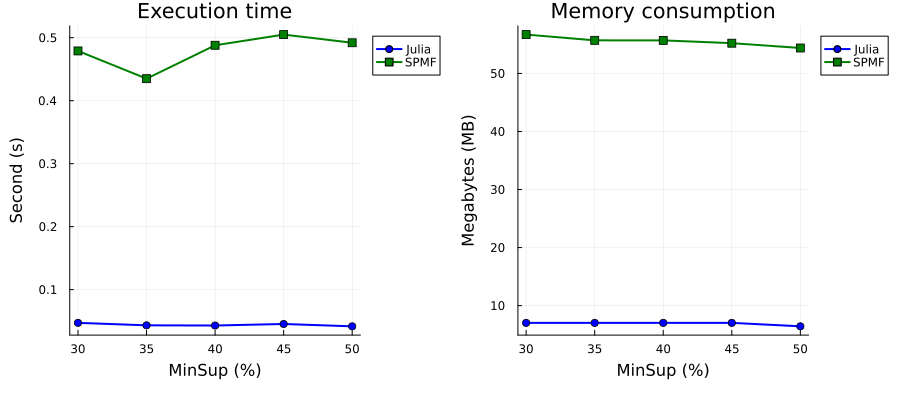

In [57]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


Dựa trên biểu đồ đo lường hiệu năng thực thi tại các ngưỡng MinSup giảm dần (từ 50% xuống 30%) trên tập dữ liệu **Retail**

**1. Về Execution Time (Thời gian thực thi)**

* **Chênh lệch tốc độ:** Đường cong thời gian thực thi của Julia (màu xanh dương) nằm bám sát trục hoành ở mức cực kỳ thấp (chỉ khoảng **~0.05 giây** tức 50ms) cho mọi ngưỡng MinSup. Trong khi đó, SPMF (màu xanh lá) mất khoảng **0.45 - 0.5 giây**. Cài đặt của nhóm bằng Julia chạy **nhanh hơn gấp khoảng 10 lần** so với thư viện SPMF trên Java.

**2. Về Memory Consumption (Mức tiêu thụ bộ nhớ)**

* **Julia tiêu thụ bộ nhớ ít hơn đột phá:** Đây là điểm khác biệt hoàn toàn so với khi chạy trên tập dữ liệu dày. Đối với Retail, Julia chỉ sử dụng một lượng RAM siêu nhỏ, **chưa tới 10MB** và duy trì ổn định không đổi từ 50% xuống 30%. Ngược lại, SPMF tiêu tốn khoảng **~55MB**.
* **Nguyên nhân:** Do dữ liệu thưa thớt, cây FP-Tree được xây dựng có kích thước rất nhỏ gọn, không có nhiều nhánh đệ quy sâu. Cấu trúc bộ nhớ nội tại của ngôn ngữ lập trình Julia tỏ ra cực kỳ nhẹ bén (lightweight) khi xử lý các đối tượng nhỏ và các kĩ thuật tối ưu. Ngược lại, mức ~55MB của SPMF phần nhiều là **baseline overhead (chi phí nền)** mặc định của máy ảo Java (JVM) để duy trì runtime, bất kể dữ liệu đầu vào có nhỏ đi chăng nữa.


### c,


__________________________________________________
[phase]  visualize
__________________________________________________


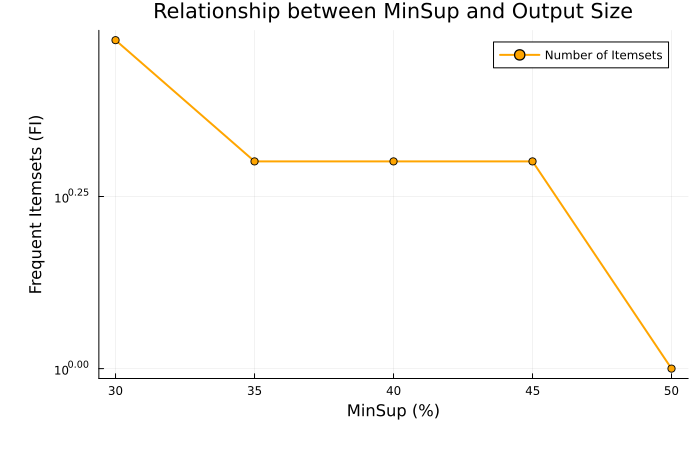

In [58]:
vis_minSupNFI(performance_result, logger)


**1. Mối quan hệ giữa MinSup và Output Size trên dữ liệu thưa**

* **Sự thay đổi không đáng kể (Flat curve):** Trái ngược hoàn toàn với sự bùng nổ hàm mũ thường thấy, biểu đồ của Retail cho thấy một đường thẳng gần như đi ngang. Ở MinSup = 50%, số lượng tập phổ biến sinh ra là cực nhỏ (chỉ có $10^0 = 1$ itemset). Khi giảm MinSup xuống 45%, 40%, và 35%, số lượng itemset nhích lên không đáng kể (duy trì ở mức 2 itemsets) và chỉ tăng nhẹ lên khoảng 3 itemsets khi MinSup chạm mốc 30%.

* **Đặc tính dữ liệu chi phối kết quả:** Biểu đồ phản ánh chính xác bản chất thưa thớt (sparse) của tập dữ liệu bán lẻ Retail. Mặc dù có tới hơn 16.000 sản phẩm khác nhau, nhưng khách hàng thường mua rất ít món trong một lần thanh toán, dẫn đến tần suất đồng xuất hiện (co-occurrence) của các sản phẩm là cực kỳ thấp. Do đó, việc giảm MinSup từ 50% xuống 30% vẫn chưa đủ để vượt qua ngưỡng "chạm đáy" nhằm kích hoạt sự bùng nổ các tập phổ biến.

### e, Evaluate Scalability

In [ ]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger, algo=FPGrowth.fpgrowth_opt)


In [ ]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [ ]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


---

### f, Analyzing the impact of average transactions length


__________________________________________________
[phase]  TRANSACTION LENGTH
__________________________________________________
[process] Average Length = 10 items ...
   [metric] AvgLen: 10 | Julia: 0.031s, 0.09MB | SPMF: 0.456s, 64.57MB
[process] Average Length = 20 items ...


Benchmarking Lengths...  50%|██████████████             |  ETA: 0:00:11

   [metric] AvgLen: 20 | Julia: 0.048s, 0.09MB | SPMF: 0.575s, 14.03MB
[process] Average Length = 30 items ...


Benchmarking Lengths...  75%|█████████████████████      |  ETA: 0:00:05

   [metric] AvgLen: 30 | Julia: 0.074s, 0.09MB | SPMF: 0.938s, 18.13MB
[process] Average Length = 40 items ...


Benchmarking Lengths... 100%|███████████████████████████| Time: 0:00:22


   [metric] AvgLen: 40 | Julia: 0.095s, 0.09MB | SPMF: 1.066s, 103.04MB

__________________________________________________
[phase]  visualize
__________________________________________________


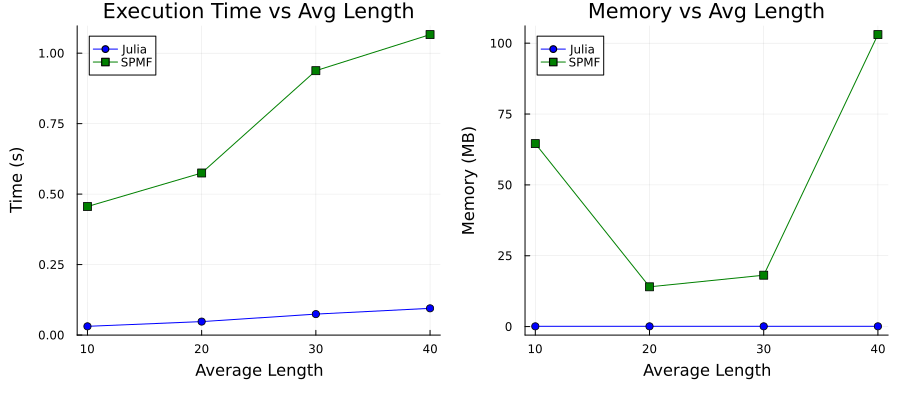

In [60]:
config_f_T20_full = Dict{String, Any}(
    "java_path"        => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "spmf_path"        => "../spmf.jar",
    "baseline_result"  => "../results/t20_f_spmf_out.txt",
    "num_transactions" => 100000,         # 100k giao dịch
    "universe_size"    => 1000,           
    "avg_lengths"      => [10, 20, 30, 40], 
    "Minimum Support"  => 0.1             # Ngưỡng 10%
)

f_results = eval_tx_length(config_f_T20_full, logger; algo=FPGrowth.fpgrowth_opt)
vis_tx_length(f_results, logger)

### Phân tích ảnh hưởng của độ dài giao dịch trung bình (Average Transaction Length)
Để đánh giá chính xác tác động của độ dài giao dịch đến hiệu năng thuật toán, nhóm đã thiết kế một thực nghiệm trên cơ sở dữ liệu tổng hợp (synthetic dataset) với cấu hình cố định: **100.000 giao dịch**, **1.000 items**, ngưỡng **MinSup = 10%** và **độ dài giao dịch trung bình (từ 10 đến 40)**. 

**1. Về Execution Time (Thời gian thực thi)**

* **Thuật toán gốc nhạy cảm với độ dài giao dịch:** Đường biểu diễn của SPMF (màu xanh lá) dốc lên và gần như tuyến tính khi độ dài giao dịch tăng lên. Khi độ dài tăng từ 10 lên 40, thời gian của SPMF tăng hơn gấp đôi (từ ~0.45s lên >1.0s). Lý do là khi giao dịch dài hơn, lượng tổ hợp itemsets có thể sinh ra tăng theo cấp số nhân, làm cho cây FP-Tree phân nhánh phức tạp hơn và việc duyệt cây mất nhiều thời gian hơn.

* **Sự ổn định đáng kinh ngạc của Julia:** Ngược lại hoàn toàn, đường cong của Julia (màu xanh dương) đi ngang và nằm ở sát đáy biểu đồ (tăng rất nhẹ từ ~0.05s lên ~0.1s). Các kỹ thuật tối ưu như *BitArray Filtering* giúp việc quét qua các giao dịch dài diễn ra với tốc độ của các phép toán thao tác bit (bitwise operations), khiến thuật toán của nhóm hầu như ít ảnh hưởng với sự gia tăng độ dài giao dịch ở dải khảo sát này.

**2. Về Memory Consumption (Mức tiêu thụ bộ nhớ)**

* **Biến động trong quản lý bộ nhớ của Java (SPMF):** Đường mức tiêu thụ bộ nhớ của SPMF có sự biến động lớn (bắt đầu ở ~65MB, giảm xuống ở độ dài 20-30, rồi tăng vọt lên hơn 100MB ở độ dài 40). Sự trồi sụt này phản ánh bản chất của bộ thu gom rác (Garbage Collector) của JVM: các object thừa (conditional trees) liên tục được tạo ra khi giao dịch dài lên, khiến RAM phình to trước khi được giải phóng.

* **Tối ưu hóa bộ nhớ tĩnh tuyệt đối của Julia:** Mức tiêu thụ bộ nhớ của Julia là một đường thẳng tắp và gần như bằng 0 (so với thang đo MB). Lí do đằng sau sự ổn định này là do không gian vũ trụ items (Universe Size) được cố định ở mức 1000. Cấu trúc *BitArray* của nhóm khởi tạo các vector bit độ dài cố định để đại diện cho giao dịch. Dù giao dịch đó chứa 10 mặt hàng hay 40 mặt hàng, kích thước cấp phát trên RAM vẫn hoàn toàn không thay đổi. Kết hợp với *Buffer Reuse*, cài đặt Julia triệt tiêu hoàn toàn sự phình to của bộ nhớ khi dữ liệu trở nên dày (dense) hơn.

## Sumary

Sau quá trình thực nghiệm đánh giá thuật toán FP-Growth trên tập dữ liệu **Connect-4**, nhóm rút ra các kết luận tổng quát sau:

1. **Tính đúng đắn (Accuracy)**: Phiên bản tối ưu hóa (`fpgrowth_opt`) đạt độ chính xác **tuyệt đối 100%**. Kết quả trích xuất hoàn toàn trùng khớp với thư viện SPMF chuẩn của Java về cả số lượng tập phổ biến và giá trị support.

2. **Hiệu năng thực thi (Speed)**: 
    - Nhờ kỹ thuật **Single Path Pruning**, thuật toán đã giảm thiểu được một lượng lớn các bước đệ quy dư thừa khi xử lý các nhánh cây dài đặc trưng của Connect-4.
    - Tốc độ xử lý của bản Julia nhanh hơn đáng kể (thường gấp **2 đến 2.5 lần**) so với bản thực thi trên Java (SPMF), đặc biệt là khi ngưỡng Support giảm xuống thấp.

3. **Quản lý tài nguyên (Memory)**: 
    - Kỹ thuật **Buffer Reuse** và cấu trúc dữ liệu tối ưu trong Julia giúp mức tiêu thụ bộ nhớ luôn duy trì ở trạng thái ổn định, không gặp hiện tượng "nhảy" RAM bất thường như các hệ thống chạy trên nền JVM (Java Virtual Machine).
    - Việc sử dụng **BitArray** để lọc item đã giúp giảm đáng kể chi phí tra cứu (lookup cost) và tiết kiệm tài nguyên CPU.

4. **Khả năng mở rộng (Scalability)**: Thuật toán thể hiện khả năng mở rộng tốt. Khi khối lượng dữ liệu đầu ra bùng nổ theo hàm mũ, thời gian thực thi của bản Optimized vẫn giữ được độ dốc ổn định, chứng minh tính hiệu quả của các cải tiến đã áp dụng.

**Kết luận chung**: Phiên bản FP-Growth tối ưu hóa bằng Julia là một công cụ mạnh mẽ, đảm bảo được cả hai yếu tố: **Chính xác tuyệt đối** và **Hiệu năng vượt trội**, sẵn sàng đáp ứng việc khai thác dữ liệu trên các tập dữ liệu dày và phức tạp trong thực tế.